<a href="https://colab.research.google.com/github/AmalKhaled28/Audiobook-Dataset-Analysis/blob/main/audiobook_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from random import sample
import seaborn as sns
from sklearn import preprocessing
import warnings
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("audiobook_data_2.csv")

In [ ]:
#the types of the attribute
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14084 entries, 0 to 14083
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       14083 non-null  float64
 1   Book_length(mins)_overall        14062 non-null  float64
 2   Book_length(mins)_avg            14079 non-null  float64
 3   Price_overall                    14076 non-null  float64
 4   Price_avg                        14064 non-null  float64
 5   Review                           14083 non-null  float64
 6   Review10/10                      14083 non-null  float64
 7   Completion                       14084 non-null  float64
 8   Minutes_listened                 14070 non-null  float64
 9   Support_Request                  14082 non-null  float64
 10  Last_Visited_mins_Purchase_date  14082 non-null  float64
 11  Target                           14084 non-null  int64  
dtypes: float64(11), in

In [ ]:
#removing irrelevant attributes and handling missing values
df.drop(['Unnamed: 0','Support_Request'],axis='columns' ,inplace=True)
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14026 entries, 0 to 14083
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Book_length(mins)_overall        14026 non-null  float64
 1   Book_length(mins)_avg            14026 non-null  float64
 2   Price_overall                    14026 non-null  float64
 3   Price_avg                        14026 non-null  float64
 4   Review                           14026 non-null  float64
 5   Review10/10                      14026 non-null  float64
 6   Completion                       14026 non-null  float64
 7   Minutes_listened                 14026 non-null  float64
 8   Last_Visited_mins_Purchase_date  14026 non-null  float64
 9   Target                           14026 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [ ]:
# Rank your values, using method='first' to have python assign a unique rank to all your records
#cat.codes to convert category to numbers
#discretization or binning
df['mins_overall'] = pd.qcut(df['Book_length(mins)_overall'].rank(method='first'), 5).cat.codes
df['mins_avg'] = pd.qcut(df['Book_length(mins)_avg'].rank(method='first'), 5).cat.codes
df['overall_price'] = pd.qcut(df['Price_overall'].rank(method='first'), 5).cat.codes
df['overall_avg'] = pd.qcut(df['Price_avg'].rank(method='first'), 5).cat.codes
df['reviewing'] = pd.qcut(df['Review'].rank(method='first'), 2).cat.codes
df['reveiw_rating'] = pd.qcut(df['Review10/10'].rank(method='first'), 5).cat.codes
df['Completion_audio'] = pd.qcut(df['Completion'].rank(method='first'), 5).cat.codes
df['mins_lis'] = pd.qcut(df['Minutes_listened'].rank(method='first'), 5).cat.codes
df['last_visit'] = pd.qcut(df['Last_Visited_mins_Purchase_date'].rank(method='first'), 5).cat.codes
df['audio_target'] = pd.qcut(df['Target'].rank(method='first'), 2).cat.codes

In [ ]:
#remove duplicate data
df.drop_duplicates(inplace = True)
print(df.duplicated())

0        False
1        False
3        False
4        False
5        False
         ...  
14079    False
14080    False
14081    False
14082    False
14083    False
Length: 10225, dtype: bool


In [ ]:
#basic statistical data
df.describe()

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,mins_overall,mins_avg,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target
count,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000,10225.000000
mean,1578.449134,1691.559902,7.394986,7.972274,0.219267,8.909066,0.171724,259.319249,84.340733,0.190905,1.946699,1.987286,2.134670,2.164205,0.515012,2.004401,2.333888,2.333790,2.536919,0.503472
std,507.620981,694.518591,5.621163,6.323164,0.413770,0.752779,0.267576,411.827920,93.094042,0.393033,1.410958,1.424905,1.427347,1.436559,0.499799,1.491657,1.442023,1.442012,1.248799,0.500012
min,216.000000,216.000000,3.860000,3.860000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1188.000000,1188.000000,5.330000,5.330000,0.000000,8.910000,0.000000,0.000000,4.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000,0.000000
50%,1620.000000,1620.000000,6.370000,6.550000,0.000000,8.910000,0.030000,43.200000,44.000000,0.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,3.000000,3.000000,3.000000,1.000000
75%,2160.000000,2160.000000,8.000000,8.000000,0.000000,8.910000,0.250000,388.800000,150.000000,0.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,4.000000,4.000000,4.000000,1.000000
max,2160.000000,7020.000000,130.940000,130.940000,1.000000,10.000000,1.000000,2160.000000,464.000000,1.000000,4.000000,4.000000,4.000000,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,1.000000


In [ ]:
# correlation of the dataset
corr = df.corr()

<AxesSubplot:>

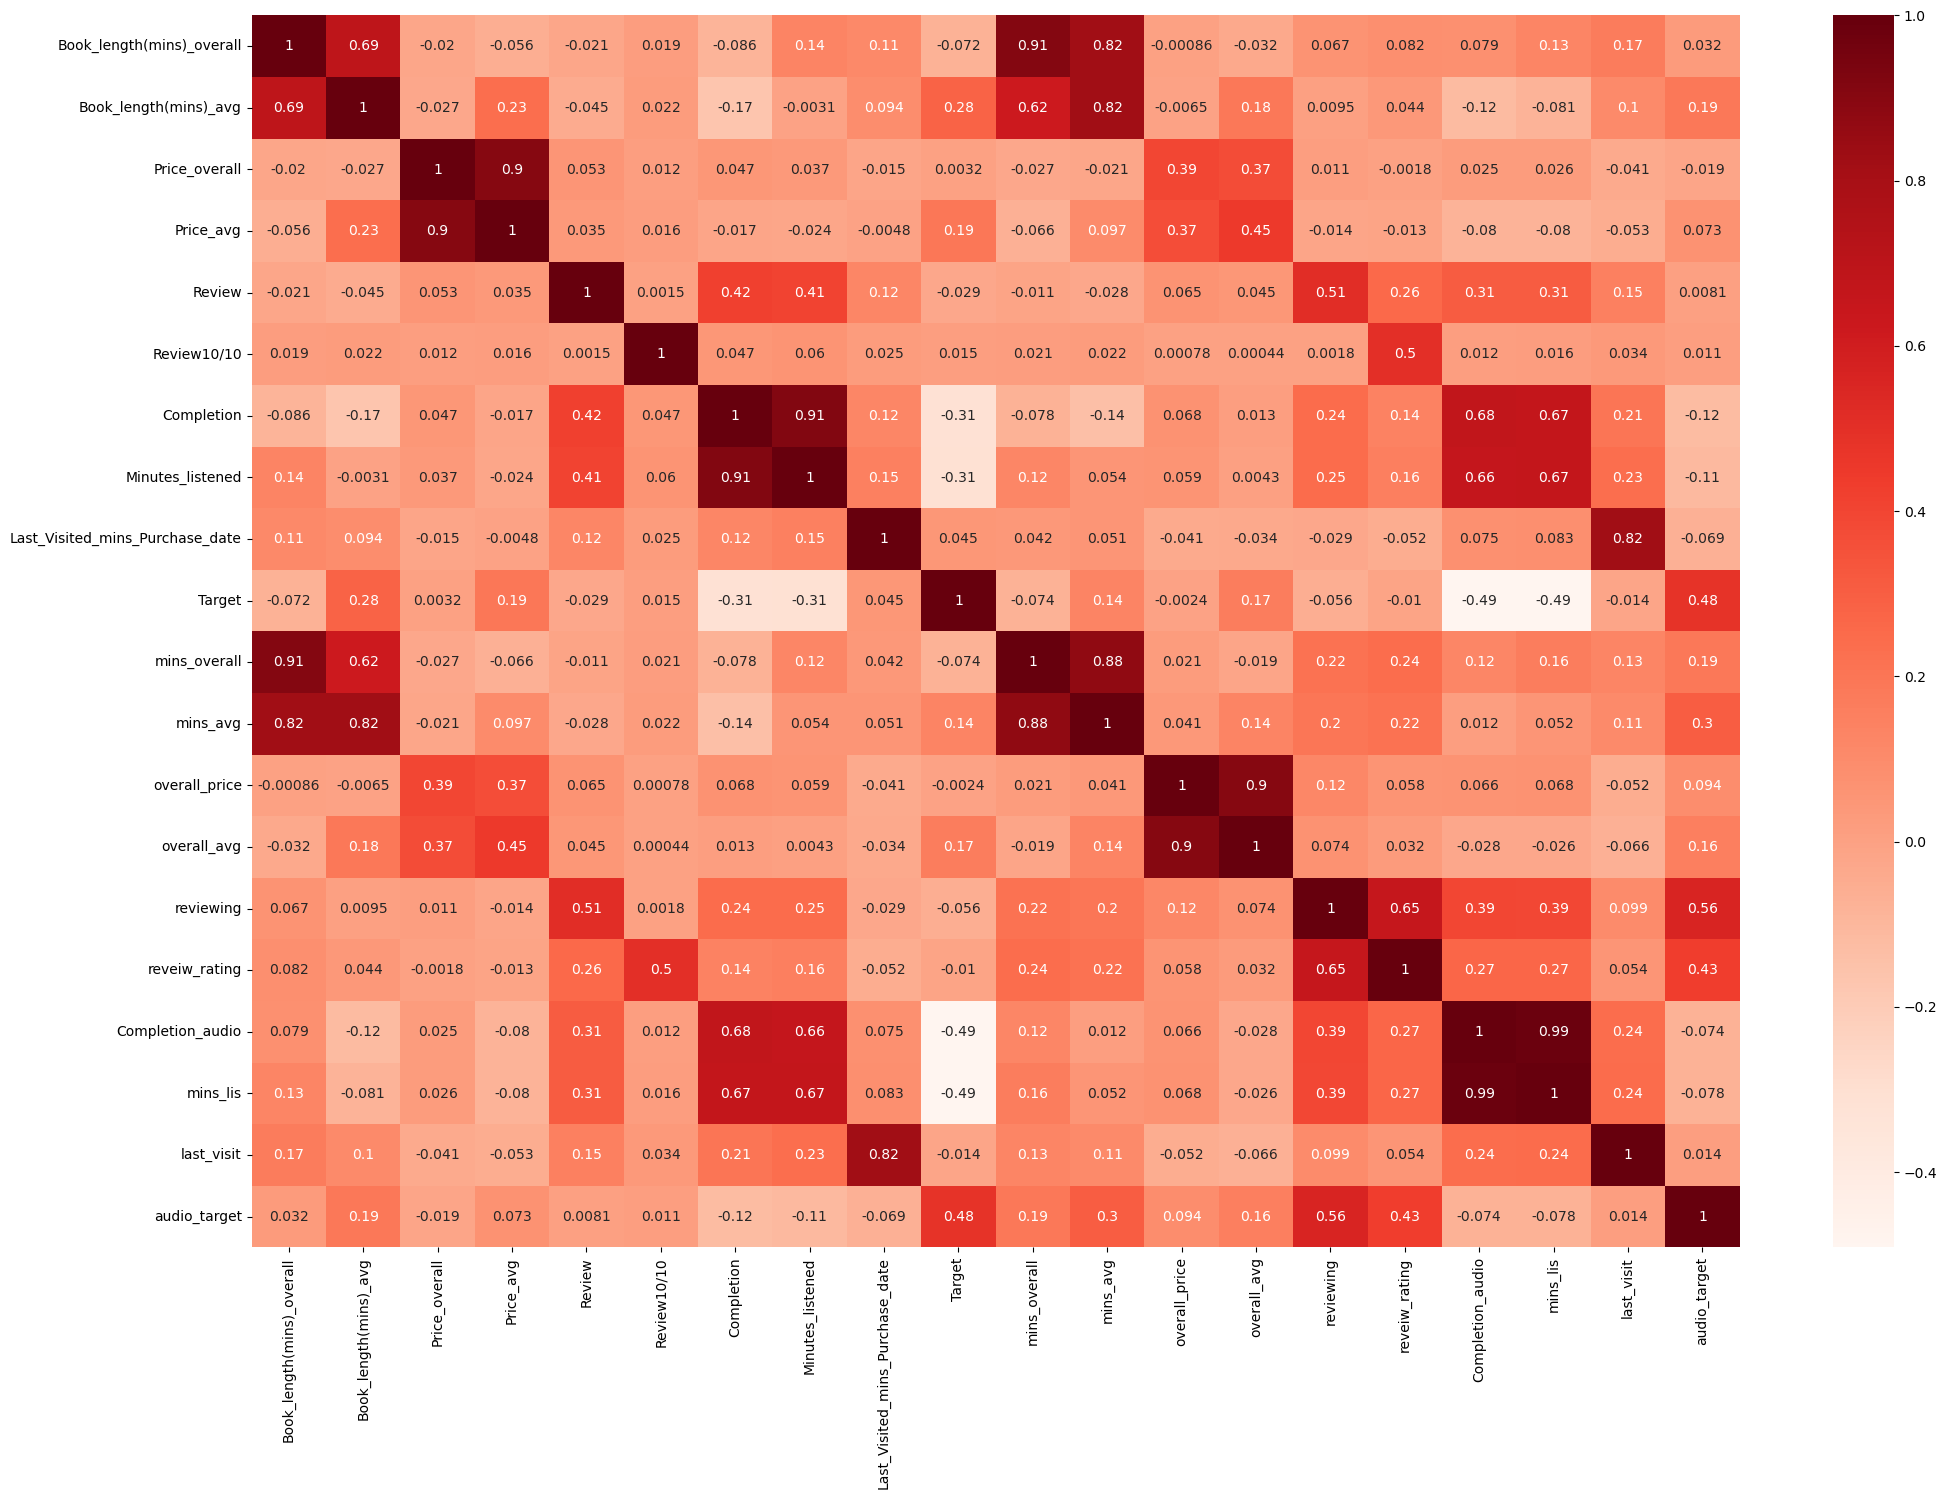

In [ ]:
#plotting the correlation
plt.figure(figsize=(24,16))
sns.heatmap(corr, cmap="Reds",annot=True)

In [ ]:
#removing highly correlated values
corr[corr <0.8 ].unstack().transpose()\
.sort_values( ascending=False)\
.drop_duplicates()

Book_length(mins)_overall  Book_length(mins)_avg        0.688082
Completion                 Completion_audio             0.679269
Minutes_listened           mins_lis                     0.666252
mins_lis                   Completion                   0.665333
Completion_audio           Minutes_listened             0.661206
                                                          ...   
Minutes_listened           Target                      -0.305878
Completion                 Target                      -0.311756
mins_lis                   Target                      -0.491248
Target                     Completion_audio            -0.491277
Book_length(mins)_overall  Book_length(mins)_overall         NaN
Length: 182, dtype: float64

In [ ]:
# standardscaler for normalization to the datset

from sklearn.preprocessing import StandardScaler

scalerstandard = StandardScaler()

scalerstandard.fit(df)

datatransformstandard = scalerstandard.transform(df)

print(datatransformstandard)

[[ 0.08185812 -0.1030403   2.19449554 ...  1.1555324   0.37083902
  -1.00696804]
 [ 1.14569596  0.67451471 -0.36737714 ... -1.618505   -2.03158692
  -1.00696804]
 [ 0.08185812 -0.1030403  -0.25529521 ...  1.1555324   0.37083902
  -1.00696804]
 ...
 [ 1.14569596  0.67451471 -0.2232718  ... -0.2314863  -1.23077828
   0.99308018]
 [ 0.08185812 -0.1030403  -0.36737714 ...  1.1555324   0.37083902
   0.99308018]
 [ 0.1882419   2.38513572 -0.36737714 ... -0.2314863  -1.23077828
   0.99308018]]


In [ ]:
#splitting data and save into files
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df, test_size=0.2, random_state=1)
train_data.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)

In [ ]:
train_data

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,mins_overall,mins_avg,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target
12522,2160.0,2160.0,5.66,5.66,0.0,8.91,0.03,64.8,8.0,0,4,4,2,2,1,3,3,3,2,1
11150,1620.0,1620.0,5.33,5.33,0.0,8.91,0.20,324.0,26.0,0,2,2,1,1,1,3,3,3,2,1
7737,1620.0,1620.0,10.66,10.66,0.0,8.91,0.00,0.0,0.0,0,2,2,4,4,0,2,1,1,0,0
10772,1620.0,1620.0,8.00,8.00,1.0,8.00,0.21,340.2,175.0,0,2,2,3,3,1,0,3,4,4,1
8454,2160.0,2160.0,5.61,5.61,0.0,8.91,0.22,475.2,130.0,0,4,4,2,2,1,2,4,4,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3711,1404.0,5616.0,5.87,23.47,0.0,8.91,0.00,0.0,56.0,1,1,4,2,4,0,1,0,0,3,1
10722,1620.0,1620.0,5.33,5.33,1.0,9.00,0.00,0.0,154.0,1,2,2,1,1,1,4,2,2,4,1
1075,2160.0,2160.0,10.13,10.13,0.0,8.91,0.00,0.0,344.0,1,3,3,4,4,0,0,0,0,4,1
6757,1620.0,1620.0,6.00,6.00,1.0,10.00,0.13,210.6,35.0,0,2,2,2,2,1,4,3,3,3,0


In [ ]:
test_data

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,mins_overall,mins_avg,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target
13739,2160.0,2160.0,8.44,8.44,1.0,1.00,0.04,86.4,1.0,0,4,4,4,4,1,0,3,3,2,1
9887,2160.0,2160.0,5.33,5.33,0.0,8.91,0.24,518.4,131.0,0,4,4,1,1,1,3,4,4,3,1
11771,2160.0,2160.0,8.00,8.00,0.0,8.91,0.01,21.6,91.0,0,4,4,4,3,1,3,3,3,3,1
12148,2160.0,2160.0,8.18,8.18,0.0,8.91,0.06,129.6,33.0,0,4,4,4,4,1,3,3,3,3,1
7016,2160.0,2160.0,8.00,8.00,1.0,10.00,0.00,0.0,32.0,1,4,3,3,3,1,4,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,1188.0,1188.0,6.37,6.37,0.0,8.91,0.00,0.0,29.0,1,1,1,2,2,0,1,0,0,2,1
6503,1890.0,3780.0,6.67,13.33,0.0,9.00,0.00,0.0,0.0,1,3,4,2,4,0,4,1,1,0,1
5119,1620.0,1620.0,7.99,7.99,0.0,8.91,0.00,0.0,59.0,0,2,2,3,3,0,1,1,1,3,0
5778,2160.0,2160.0,10.13,10.13,0.0,8.91,0.01,21.6,203.0,0,3,3,4,4,0,1,2,3,4,0


In [ ]:
inputs = df.drop('Review',axis='columns')
target = df['Review']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2, random_state=1)

In [ ]:
#naive bayes by guass
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()

In [ ]:

model.fit(X_train,y_train)

GaussianNB()

In [ ]:
#score automates the prediction of your data using X_test and compares it with Y_test
model.score(X_test,y_test)

0.8982885085574572

In [ ]:
y_test[0:10]

13739    1.0
9887     0.0
11771    0.0
12148    0.0
7016     1.0
10201    0.0
4102     0.0
7490     0.0
7210     1.0
4315     1.0
Name: Review, dtype: float64

In [ ]:
 model.predict(X_test[0:10])

array([1., 1., 0., 0., 1., 0., 0., 0., 1., 1.])

In [ ]:
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn import tree


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2, random_state=1)

In [ ]:
# Create Decision Tree classifer object
# shift and 3tab display parameter
Model = tree.DecisionTreeClassifier()

In [ ]:

# Train Decision Tree Classifer
Model.fit(X_train,y_train)


DecisionTreeClassifier()

In [ ]:

#Predict the response for test dataset
#score automates the prediction of your data using X_test and compares it with Y_test
Model.score(X_test,y_test)


0.9897310513447433

In [ ]:

X_test


,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,mins_overall,mins_avg,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target
13739,2160.0,2160.0,8.44,8.44,1.00,0.04,86.4,1.0,0,4,4,4,4,1,0,3,3,2,1
9887,2160.0,2160.0,5.33,5.33,8.91,0.24,518.4,131.0,0,4,4,1,1,1,3,4,4,3,1
11771,2160.0,2160.0,8.00,8.00,8.91,0.01,21.6,91.0,0,4,4,4,3,1,3,3,3,3,1
12148,2160.0,2160.0,8.18,8.18,8.91,0.06,129.6,33.0,0,4,4,4,4,1,3,3,3,3,1
7016,2160.0,2160.0,8.00,8.00,10.00,0.00,0.0,32.0,1,4,3,3,3,1,4,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461,1188.0,1188.0,6.37,6.37,8.91,0.00,0.0,29.0,1,1,1,2,2,0,1,0,0,2,1
6503,1890.0,3780.0,6.67,13.33,9.00,0.00,0.0,0.0,1,3,4,2,4,0,4,1,1,0,1
5119,1620.0,1620.0,7.99,7.99,8.91,0.00,0.0,59.0,0,2,2,3,3,0,1,1,1,3,0
5778,2160.0,2160.0,10.13,10.13,8.91,0.01,21.6,203.0,0,3,3,4,4,0,1,2,3,4,0


In [ ]:

y_test

13739    1.0
9887     0.0
11771    0.0
12148    0.0
7016     1.0
        ... 
4461     0.0
6503     0.0
5119     0.0
5778     0.0
7294     0.0
Name: Review, Length: 2045, dtype: float64

In [ ]:
y_pred= Model.predict(X_test)
y_pred


array([1., 0., 0., ..., 0., 0., 0.])

[Text(0.26477272727272727, 0.9642857142857143, 'X[4] <= 8.955\ngini = 0.344\nsamples = 8180\nvalue = [6377, 1803]'),
 Text(0.1, 0.8928571428571429, 'X[4] <= 8.79\ngini = 0.153\nsamples = 6838\nvalue = [6266, 572]'),
 Text(0.08181818181818182, 0.8214285714285714, 'X[13] <= 0.5\ngini = 0.135\nsamples = 617\nvalue = [45, 572]'),
 Text(0.06363636363636363, 0.75, 'gini = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.1, 0.75, 'X[8] <= 0.5\ngini = 0.047\nsamples = 586\nvalue = [14, 572]'),
 Text(0.08181818181818182, 0.6785714285714286, 'gini = 0.0\nsamples = 482\nvalue = [0, 482]'),
 Text(0.11818181818181818, 0.6785714285714286, 'X[7] <= 1.5\ngini = 0.233\nsamples = 104\nvalue = [14, 90]'),
 Text(0.05454545454545454, 0.6071428571428571, 'X[10] <= 3.5\ngini = 0.499\nsamples = 21\nvalue = [10, 11]'),
 Text(0.03636363636363636, 0.5357142857142857, 'X[4] <= 5.25\ngini = 0.391\nsamples = 15\nvalue = [4, 11]'),
 Text(0.01818181818181818, 0.4642857142857143, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'

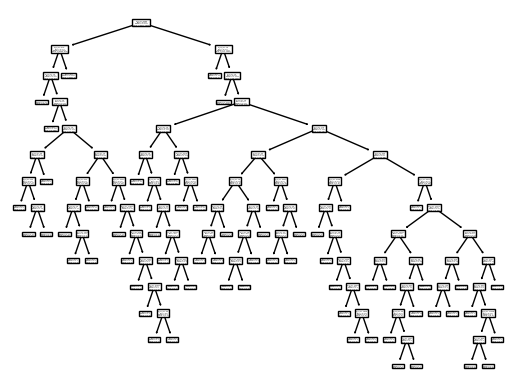

In [ ]:

tree.plot_tree(Model)


In [ ]:

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))



Accuracy: 0.9897310513447433


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))

[[1596   10]
 [  11  428]]


In [ ]:
#knn
from sklearn import metrics
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs,target,test_size=0.2)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

In [ ]:
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4)


In [ ]:
#
# Train knn Classifer
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [ ]:
print(knn.score(X_test, y_test))

0.9745721271393643


In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
y_pred

array([0., 0., 0., ..., 1., 0., 0.])

In [ ]:
y_test

10015    0.0
4570     0.0
10716    0.0
4611     1.0
8724     0.0
        ... 
10510    0.0
9609     0.0
13490    1.0
5224     0.0
4159     0.0
Name: Review, Length: 2045, dtype: float64

In [ ]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))



Accuracy: 0.9745721271393643


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))


[[1585    9]
 [  43  408]]


In [ ]:
#create a for loop that trains various KNN models with different k values,
#then keep track of the error_rate for each of these models with a list.

error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error rate')

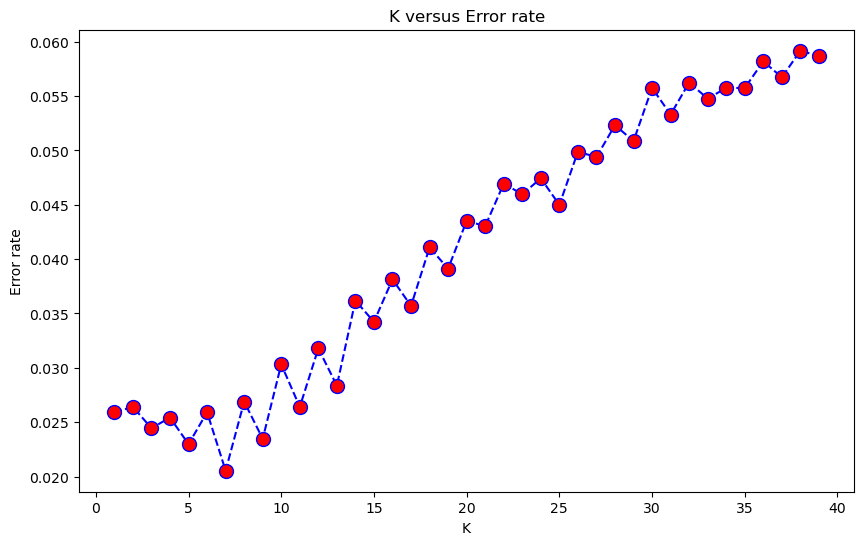

In [ ]:
#plot the error rate with the k value
plt.figure(figsize=(10, 6))

plt.plot(range(1, 40), error_rate, color='blue', linestyle='--', markersize=10, markerfacecolor='red', marker='o')

plt.title('K versus Error rate')

plt.xlabel('K')
plt.ylabel('Error rate')

In [ ]:
#testing the one that has the lowest error rate
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)

print(confusion_matrix(y_test, y_pred))


[[1585    9]
 [  43  408]]


In [ ]:
#kmeans
#kmeans clustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [ ]:
#transforming the columns
scaler = MinMaxScaler()

scaler.fit_transform(df[['Price_overall']])
scaler.fit_transform(df[['Book_length(mins)_overall']])

array([[0.72222222],
       [1.        ],
       [0.72222222],
       ...,
       [1.        ],
       [0.72222222],
       [0.75      ]])

Text(0, 0.5, 'Book_length(mins)_overall')

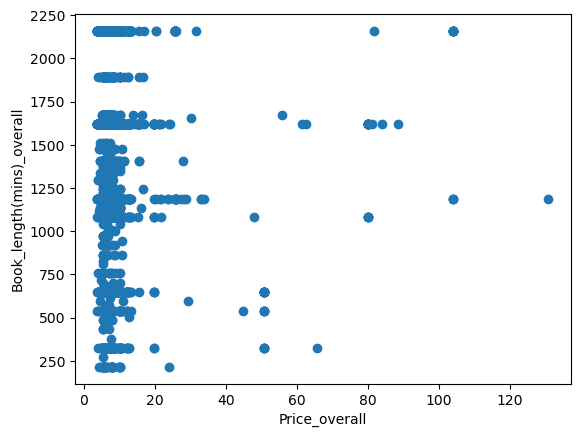

In [ ]:
#plotting
plt.scatter(df.Price_overall,df['Book_length(mins)_overall'])
plt.xlabel('Price_overall')
plt.ylabel('Book_length(mins)_overall')


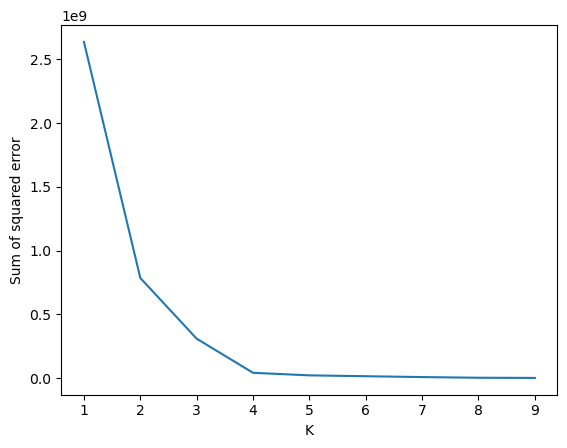

In [ ]:
#elbow method
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Price_overall','Book_length(mins)_overall']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=4)
y_predicted = km.fit_predict(df[['Price_overall','Book_length(mins)_overall']])
y_predicted

array([2, 0, 2, ..., 0, 2, 2])

In [ ]:
#saving the kmeans inside the cluster
df['cluster']=y_predicted
df

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,mins_avg,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target,cluster
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,1,4,4,1,4,4,4,3,0,2
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,3,0,0,0,0,0,0,0,0,0
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,1,2,2,0,0,4,4,3,0,2
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,3,0,0,0,0,3,4,4,0,0
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,3,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14079,1620.0,1620.0,5.33,5.33,1.0,9.00,0.61,988.2,4.0,0,...,3,2,1,1,4,4,4,2,1,2
14080,1080.0,1080.0,6.55,6.55,1.0,6.00,0.29,313.2,29.0,0,...,0,2,2,1,0,4,3,2,1,1
14081,2160.0,2160.0,6.14,6.14,0.0,8.91,0.00,0.0,0.0,0,...,4,2,2,1,4,2,2,1,1,0
14082,1620.0,1620.0,5.33,5.33,1.0,8.00,0.38,615.6,90.0,0,...,3,2,1,1,0,4,4,3,1,2


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[   7.33816075, 2152.39659724],
       [   7.18095802, 1167.37076336],
       [   7.42575186, 1613.41986386],
       [   8.07448133,  548.79460581]])

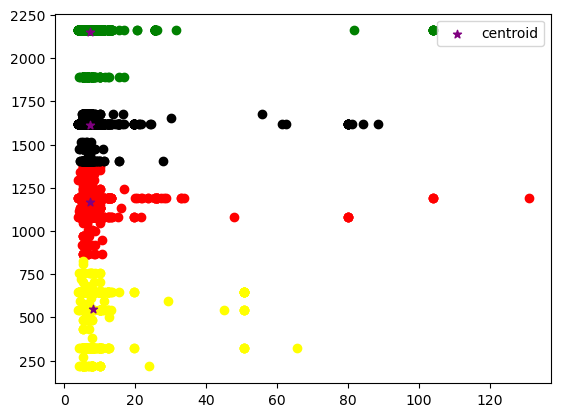

In [ ]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
df4 = df[df.cluster==3]
plt.scatter(df1['Price_overall'],df1['Book_length(mins)_overall'],color='green')
plt.scatter(df2['Price_overall'],df2['Book_length(mins)_overall'],color='red')
plt.scatter(df3['Price_overall'],df3['Book_length(mins)_overall'],color='black')
plt.scatter(df4['Price_overall'],df4['Book_length(mins)_overall'],color='yellow')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

scaler.fit_transform(df[['Price_avg']])
scaler.fit_transform(df[['Book_length(mins)_avg']])

array([[0.20634921],
       [0.28571429],
       [0.20634921],
       ...,
       [0.28571429],
       [0.20634921],
       [0.46031746]])

Text(0, 0.5, 'Book_length(mins)_avg')

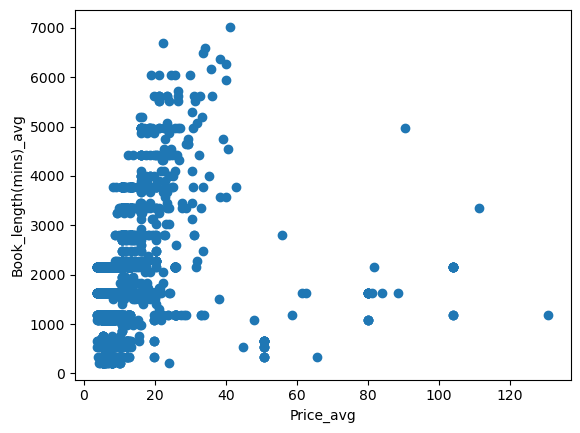

In [ ]:
plt.scatter(df.Price_avg,df['Book_length(mins)_avg'])
plt.xlabel('Price_avg')
plt.ylabel('Book_length(mins)_avg')

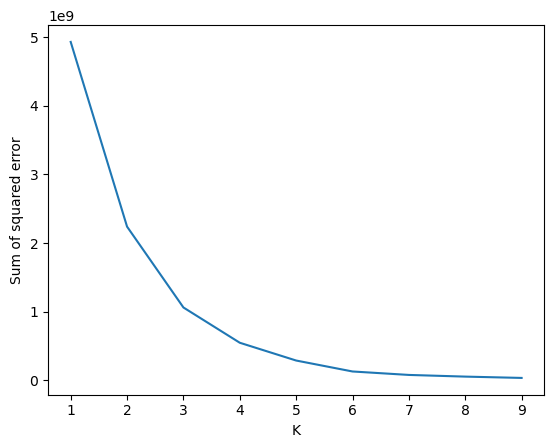

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Price_avg','Book_length(mins)_avg']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=4)
y_predicted = km.fit_predict(df[['Price_avg','Book_length(mins)_avg']])
y_predicted

array([3, 0, 3, ..., 0, 3, 2])

In [ ]:
df['cluster1']=y_predicted
df

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,overall_price,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target,cluster,cluster1
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,4,4,1,4,4,4,3,0,2,3
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,2,2,0,0,4,4,3,0,2,3
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,0,0,0,0,3,4,4,0,0,0
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14079,1620.0,1620.0,5.33,5.33,1.0,9.00,0.61,988.2,4.0,0,...,2,1,1,4,4,4,2,1,2,3
14080,1080.0,1080.0,6.55,6.55,1.0,6.00,0.29,313.2,29.0,0,...,2,2,1,0,4,3,2,1,1,1
14081,2160.0,2160.0,6.14,6.14,0.0,8.91,0.00,0.0,0.0,0,...,2,2,1,4,2,2,1,1,0,0
14082,1620.0,1620.0,5.33,5.33,1.0,8.00,0.38,615.6,90.0,0,...,2,1,1,0,4,4,3,1,2,3


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[   7.75095645, 2184.3176772 ],
       [   7.49686866,  995.98567164],
       [  18.37804598, 4025.17241379],
       [   7.55717319, 1620.89581951]])

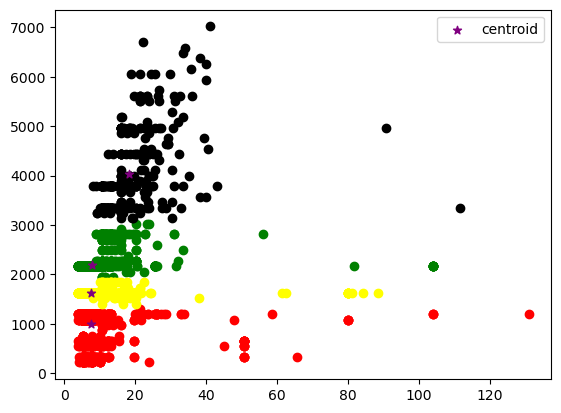

In [ ]:
df1 = df[df.cluster1==0]
df2 = df[df.cluster1==1]
df3 = df[df.cluster1==2]
df4 = df[df.cluster1==3]
plt.scatter(df1['Price_avg'],df1['Book_length(mins)_avg'],color='green')
plt.scatter(df2['Price_avg'],df2['Book_length(mins)_avg'],color='red')
plt.scatter(df3['Price_avg'],df3['Book_length(mins)_avg'],color='black')
plt.scatter(df4['Price_avg'],df4['Book_length(mins)_avg'],color='yellow')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

scaler.fit_transform(df[['Minutes_listened']])
scaler.fit_transform(df[['Book_length(mins)_overall']])

array([[0.72222222],
       [1.        ],
       [0.72222222],
       ...,
       [1.        ],
       [0.72222222],
       [0.75      ]])

Text(0, 0.5, 'Book_length(mins)_overall')

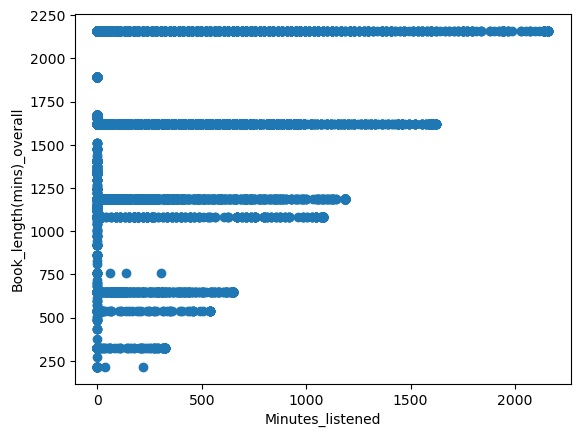

In [ ]:
plt.scatter(df.Minutes_listened,df['Book_length(mins)_overall'])
plt.xlabel('Minutes_listened')
plt.ylabel('Book_length(mins)_overall')

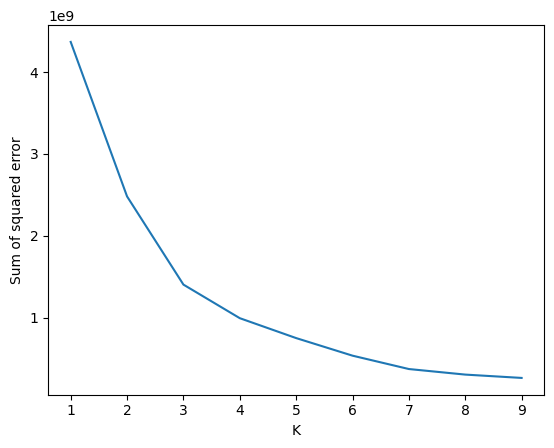

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Minutes_listened','Book_length(mins)_overall']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Minutes_listened','Book_length(mins)_overall']])
y_predicted

array([1, 0, 1, ..., 0, 1, 0])

In [ ]:
df['cluster2']=y_predicted
df

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,overall_avg,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target,cluster,cluster1,cluster2
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,4,1,4,4,4,3,0,2,3,1
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,2,0,0,4,4,3,0,2,3,1
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,0,0,0,3,4,4,0,0,0,0
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14079,1620.0,1620.0,5.33,5.33,1.0,9.00,0.61,988.2,4.0,0,...,1,1,4,4,4,2,1,2,3,1
14080,1080.0,1080.0,6.55,6.55,1.0,6.00,0.29,313.2,29.0,0,...,2,1,0,4,3,2,1,1,1,2
14081,2160.0,2160.0,6.14,6.14,0.0,8.91,0.00,0.0,0.0,0,...,2,1,4,2,2,1,1,0,0,0
14082,1620.0,1620.0,5.33,5.33,1.0,8.00,0.38,615.6,90.0,0,...,1,1,0,4,4,3,1,2,3,1


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[ 111.27557939, 1904.23175637],
       [1071.09722293, 1755.24076433],
       [ 113.26350612, 1002.30646476]])

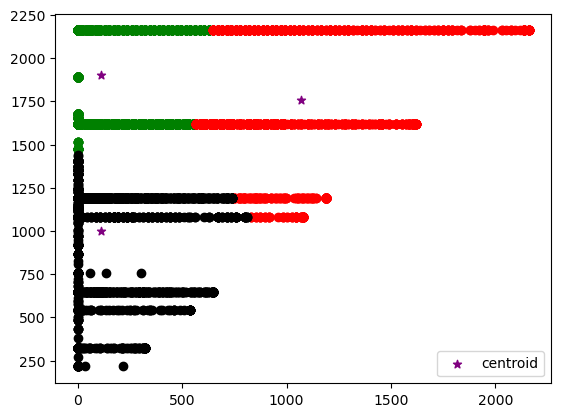

In [ ]:
df1 = df[df.cluster2==0]
df2 = df[df.cluster2==1]
df3 = df[df.cluster2==2]

plt.scatter(df1['Minutes_listened'],df1['Book_length(mins)_overall'],color='green')
plt.scatter(df2['Minutes_listened'],df2['Book_length(mins)_overall'],color='red')
plt.scatter(df3['Minutes_listened'],df3['Book_length(mins)_overall'],color='black')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

scaler.fit_transform(df[['Review10/10']])
scaler.fit_transform(df[['Completion']])

array([[0.99],
       [0.  ],
       [0.42],
       ...,
       [0.  ],
       [0.38],
       [0.  ]])

Text(0, 0.5, 'Completion')

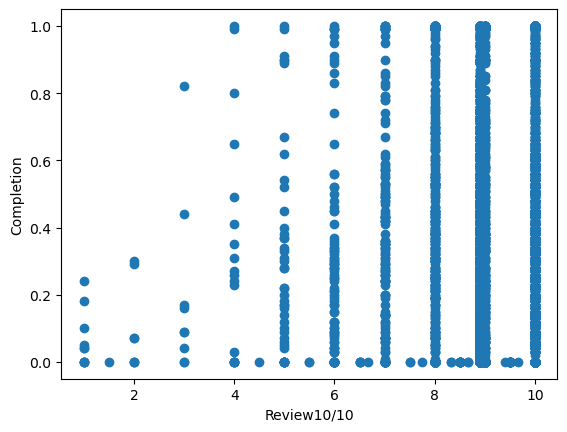

In [ ]:
plt.scatter(df['Review10/10'],df.Completion)
plt.xlabel('Review10/10')
plt.ylabel('Completion')

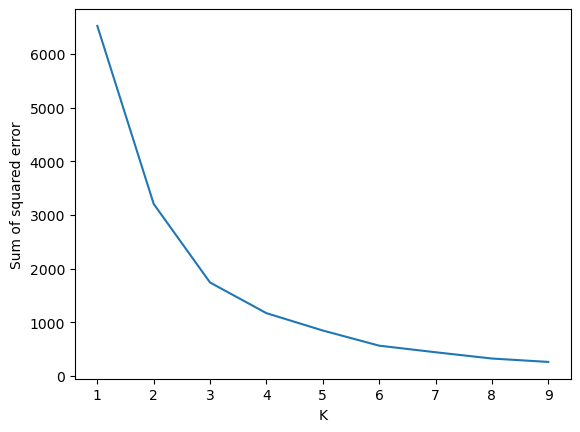

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Review10/10', 'Completion']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Review10/10', 'Completion']])
y_predicted

array([0, 2, 2, ..., 2, 2, 2])

In [ ]:
df['cluster3']=y_predicted
df

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,reviewing,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target,cluster,cluster1,cluster2,cluster3
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,1,4,4,4,3,0,2,3,1,0
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,2
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,0,0,4,4,3,0,2,3,1,2
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,0,0,3,4,4,0,0,0,0,2
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14079,1620.0,1620.0,5.33,5.33,1.0,9.00,0.61,988.2,4.0,0,...,1,4,4,4,2,1,2,3,1,2
14080,1080.0,1080.0,6.55,6.55,1.0,6.00,0.29,313.2,29.0,0,...,1,0,4,3,2,1,1,1,2,1
14081,2160.0,2160.0,6.14,6.14,0.0,8.91,0.00,0.0,0.0,0,...,1,4,2,2,1,1,0,0,0,2
14082,1620.0,1620.0,5.33,5.33,1.0,8.00,0.38,615.6,90.0,0,...,1,0,4,4,3,1,2,3,1,2


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[9.99161115, 0.35958172],
       [5.91199438, 0.29070225],
       [8.8705246 , 0.13851364]])

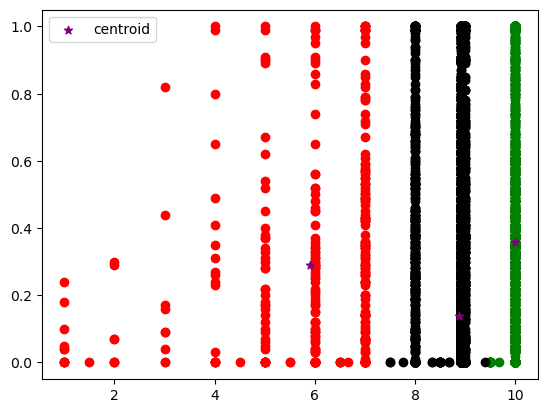

In [ ]:
df1 = df[df.cluster3==0]
df2 = df[df.cluster3==1]
df3 = df[df.cluster3==2]
plt.scatter(df1['Review10/10'],df1['Completion'],color='green')
plt.scatter(df2['Review10/10'],df2['Completion'],color='red')
plt.scatter(df3['Review10/10'],df3['Completion'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

scaler.fit_transform(df[['Review']])
scaler.fit_transform(df[['Completion']])

array([[0.99],
       [0.  ],
       [0.42],
       ...,
       [0.  ],
       [0.38],
       [0.  ]])

Text(0, 0.5, 'Completion')

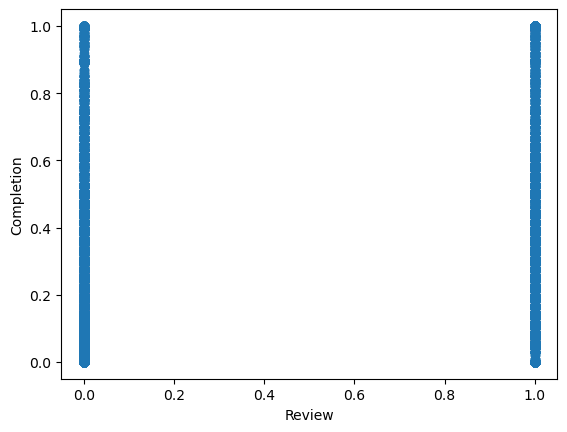

In [ ]:
plt.scatter(df['Review'],df.Completion)
plt.xlabel('Review')
plt.ylabel('Completion')

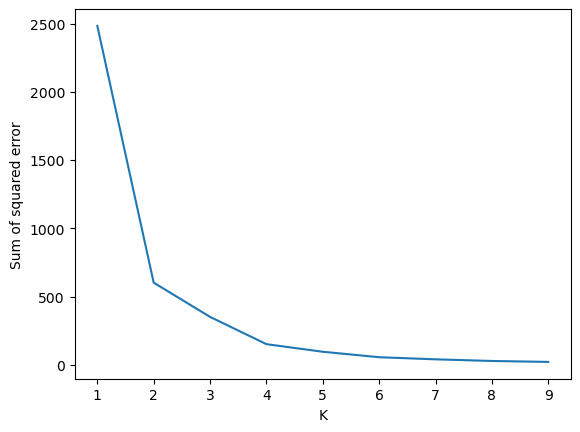

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Review', 'Completion']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=4)
y_predicted = km.fit_predict(df[['Review', 'Completion']])
y_predicted

array([2, 1, 3, ..., 1, 0, 1])

In [ ]:
df['cluster4']=y_predicted
df.head()

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,reveiw_rating,Completion_audio,mins_lis,last_visit,audio_target,cluster,cluster1,cluster2,cluster3,cluster4
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,4,4,4,3,0,2,3,1,0,2
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,2,1
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,0,4,4,3,0,2,3,1,2,3
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,0,3,4,4,0,0,0,0,2,1
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,0,2,1


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[ 1.00000000e+00,  1.63268966e-01],
       [-1.27675648e-15,  4.45716746e-02],
       [ 1.00000000e+00,  7.87638889e-01],
       [-8.32667268e-17,  5.76637081e-01]])

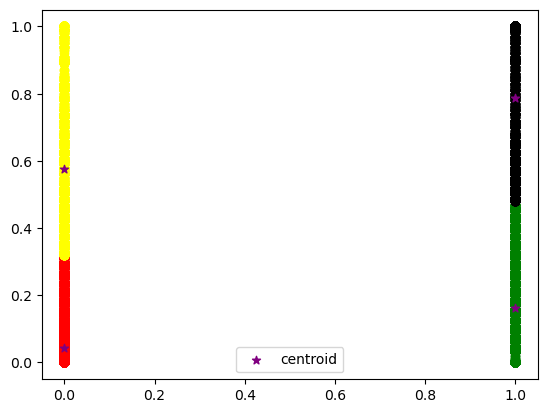

In [ ]:
df1 = df[df.cluster4==0]
df2 = df[df.cluster4==1]
df3 = df[df.cluster4==2]
df4 = df[df.cluster4==3]
plt.scatter(df1['Review'],df1['Completion'],color='green')
plt.scatter(df2['Review'],df2['Completion'],color='red')
plt.scatter(df3['Review'],df3['Completion'],color='black')
plt.scatter(df4['Review'],df4['Completion'],color='yellow')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
#Last_Visited_mins_Purchase_date
scaler = MinMaxScaler()

scaler.fit_transform(df[['Last_Visited_mins_Purchase_date']])
scaler.fit_transform(df[['Target']])

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [1.]])

Text(0, 0.5, 'Target')

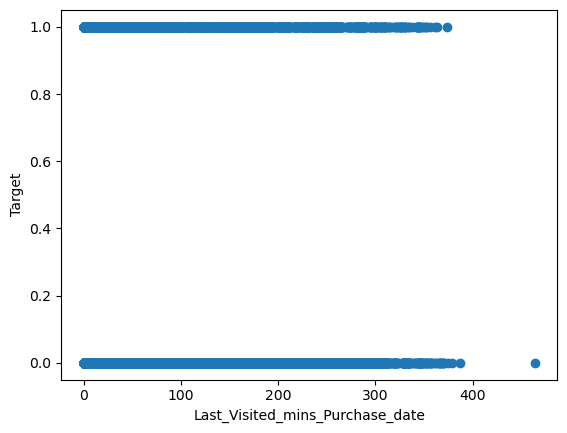

In [ ]:
plt.scatter(df['Last_Visited_mins_Purchase_date'],df.Target)
plt.xlabel('Last_Visited_mins_Purchase_date')
plt.ylabel('Target')

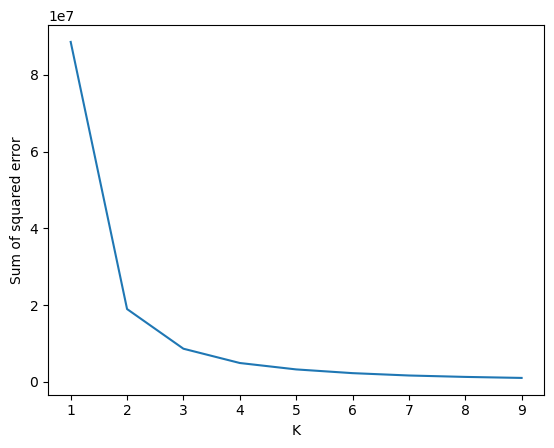

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Last_Visited_mins_Purchase_date','Target']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Last_Visited_mins_Purchase_date','Target']])
y_predicted

array([2, 1, 2, ..., 1, 2, 1])

In [ ]:
df['cluster5']=y_predicted
df

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,Completion_audio,mins_lis,last_visit,audio_target,cluster,cluster1,cluster2,cluster3,cluster4,cluster5
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,4,4,3,0,2,3,1,0,2,2
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,2,1,1
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,4,4,3,0,2,3,1,2,3,2
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,3,4,4,0,0,0,0,2,1,0
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14079,1620.0,1620.0,5.33,5.33,1.0,9.00,0.61,988.2,4.0,0,...,4,4,2,1,2,3,1,2,2,1
14080,1080.0,1080.0,6.55,6.55,1.0,6.00,0.29,313.2,29.0,0,...,4,3,2,1,1,1,2,1,0,1
14081,2160.0,2160.0,6.14,6.14,0.0,8.91,0.00,0.0,0.0,0,...,2,2,1,1,0,0,0,2,1,1
14082,1620.0,1620.0,5.33,5.33,1.0,8.00,0.38,615.6,90.0,0,...,4,4,3,1,2,3,1,2,0,2


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[2.46221267e+02, 2.15359828e-01],
       [1.67203304e+01, 1.75994606e-01],
       [1.25353764e+02, 2.08556150e-01]])

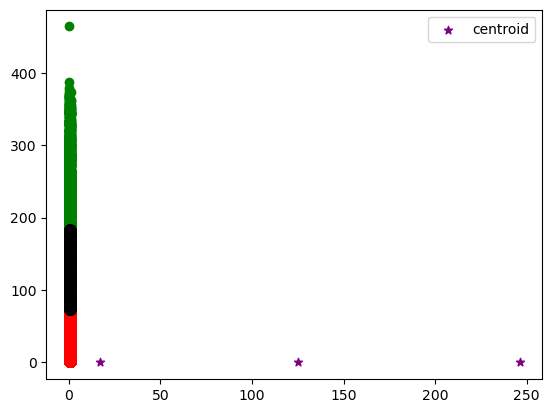

In [ ]:
df1 = df[df.cluster5==0]
df2 = df[df.cluster5==1]
df3 = df[df.cluster5==2]
plt.scatter(df1['Target'],df1['Last_Visited_mins_Purchase_date'],color='green')
plt.scatter(df2['Target'],df2['Last_Visited_mins_Purchase_date'],color='red')
plt.scatter(df3['Target'],df3['Last_Visited_mins_Purchase_date'],color='black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [ ]:
scaler = MinMaxScaler()

scaler.fit_transform(df[['last_visit']])
scaler.fit_transform(df[['audio_target']])

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [1.]])

Text(0, 0.5, 'audio_target')

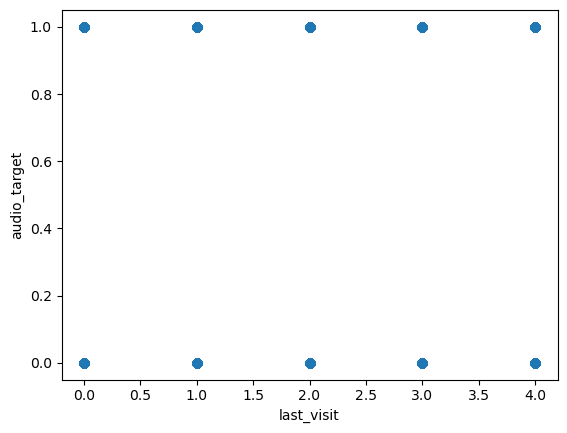

In [ ]:
plt.scatter(df.last_visit,df.audio_target)
plt.xlabel('last_visit')
plt.ylabel('audio_target')

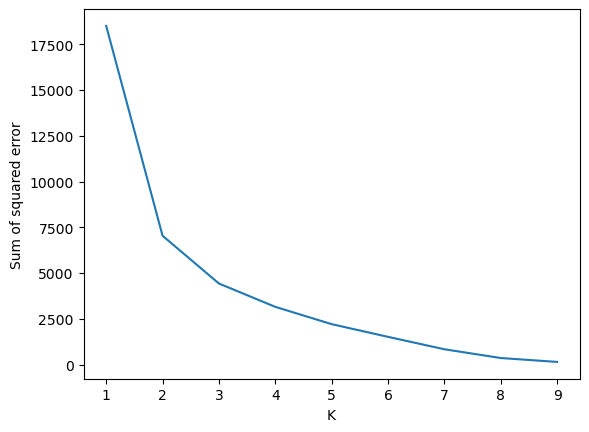

In [ ]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['last_visit','audio_target']])
    sse.append(km.inertia_)
    plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)

In [ ]:
km = KMeans(n_clusters=2)
y_predicted = km.fit_predict(df[['last_visit','audio_target']])
y_predicted

array([0, 1, 0, ..., 1, 0, 1])

In [ ]:
df['cluster6']=y_predicted
df.head()

,Book_length(mins)_overall,Book_length(mins)_avg,Price_overall,Price_avg,Review,Review10/10,Completion,Minutes_listened,Last_Visited_mins_Purchase_date,Target,...,mins_lis,last_visit,audio_target,cluster,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6
0,1620.0,1620.0,19.73,19.73,1.0,10.00,0.99,1603.8,92.0,0,...,4,3,0,2,3,1,0,2,2,0
1,2160.0,2160.0,5.33,5.33,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,2,1,1,1
3,1620.0,1620.0,5.96,5.96,0.0,8.91,0.42,680.4,129.0,0,...,4,3,0,2,3,1,2,3,2,0
4,2160.0,2160.0,5.33,5.33,0.0,8.91,0.22,475.2,361.0,0,...,4,4,0,0,0,0,2,1,0,0
5,2160.0,2160.0,4.61,4.61,0.0,8.91,0.00,0.0,0.0,0,...,0,0,0,0,0,0,2,1,1,1


In [ ]:
#Final locations of the centroid
km.cluster_centers_

array([[3.50044699, 0.49669229],
       [1.37348877, 0.51165803]])

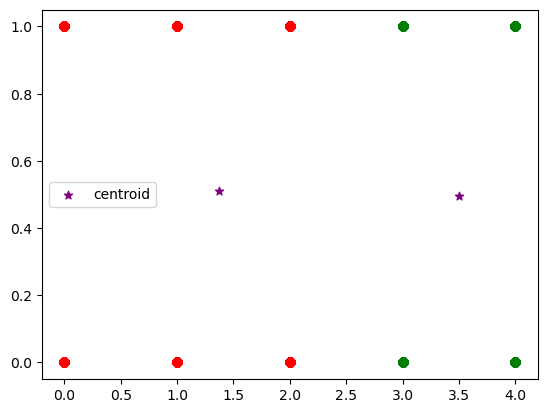

In [ ]:
df1 = df[df.cluster6==0]
df2 = df[df.cluster6==1]


plt.scatter(df1['last_visit'],df1['audio_target'],color='green')
plt.scatter(df2['last_visit'],df2['audio_target'],color='red')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()